In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import norm
from IPython.display import display

# ============================================================
# Global style (Nature / Nat. Commun. style)
# ============================================================
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
    "legend.frameon": False
})

# ============================================================
# Data / columns
# ============================================================
def first_existing(paths):
    for path in paths:
        path = Path(path)
        if path.exists():
            return path
    raise FileNotFoundError("None of these files exist: " + ", ".join(map(str, paths)))

DATA_PATH = first_existing([
    "data.xlsx",
    "../../data.xlsx",
])

OUR_OOF_PATH = first_existing([
    "cv_oof_predictions.xlsx",
    "checkpoints/cv_oof_predictions.xlsx",
    "../../checkpoints/cv_oof_predictions.xlsx",
])

df = pd.read_excel(DATA_PATH).reset_index(drop=True)
our_oof = pd.read_excel(OUR_OOF_PATH).reset_index(drop=True)

feature_cols = [
    "Al", "Co", "Cr", "Fe", "Ni", "Ti", "Mo", "Nb",
    "Eutectic", "Preparation", "Processing", "Cold CR_%",
    "Annealing_Temp_K", "Annealing_time_h", "Aging_Temp_K", "Aging_Time_h",
    "Rate_S-1", "Tensile/compress", "Tes_Temp_K",
]
target_cols = ["Strength_MPa", "Plasticity_%"]

X = df[feature_cols]
y = df[target_cols]

# ============================================================
# Models: evaluated by 5-fold OOF prediction, then concatenated
# ============================================================
models = {
    "RF": RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1),
    "GBDT": GradientBoostingRegressor(n_estimators=500, random_state=42),
    "SVR": SVR(C=10, epsilon=0.1, kernel="rbf"),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=20000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=20000),
    "KNN": KNeighborsRegressor(n_neighbors=10)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

our_pred_cols = {
    "Strength_MPa": "ATOM_OOF_Predicted_Strength_MPa",
    "Plasticity_%": "ATOM_OOF_Predicted_Plasticity_%",
}
missing_our_cols = [col for col in our_pred_cols.values() if col not in our_oof.columns]
if missing_our_cols:
    raise ValueError(
        f"Missing columns in {OUR_OOF_PATH}: {missing_our_cols}. "
        "Run `python trainer.py` first to generate clean ATOM OOF predictions."
    )


In [2]:
def five_fold_oof_predictions(X, y_target, models, cv):
    """Return model -> OOF prediction. Metrics are computed after all folds are concatenated."""
    y_target = np.asarray(y_target)
    oof = {}
    for name, model in models.items():
        pred = np.zeros(len(y_target), dtype=float)
        for train_idx, test_idx in cv.split(X):
            fold_model = clone(model)
            fold_model.fit(X.iloc[train_idx], y_target[train_idx])
            pred[test_idx] = fold_model.predict(X.iloc[test_idx])
        oof[name] = pred
    return oof

strength_oof = five_fold_oof_predictions(X, y["Strength_MPa"].values, models, cv)
plasticity_oof = five_fold_oof_predictions(X, y["Plasticity_%"].values, models, cv)

strength_oof["OurModel"] = our_oof[our_pred_cols["Strength_MPa"]].values
plasticity_oof["OurModel"] = our_oof[our_pred_cols["Plasticity_%"]].values

def residuals_and_metrics(y_true, predictions):
    residuals = {}
    metrics = {}
    for name, pred in predictions.items():
        residuals[name] = pred - y_true
        metrics[name] = {
            "R2": r2_score(y_true, pred),
            "MAE": mean_absolute_error(y_true, pred),
            "RMSE": mean_squared_error(y_true, pred, squared=False),
        }
    return residuals, metrics

strength_residuals, strength_metrics = residuals_and_metrics(
    y["Strength_MPa"].values,
    strength_oof,
)
plasticity_residuals, plasticity_metrics = residuals_and_metrics(
    y["Plasticity_%"].values,
    plasticity_oof,
)


/Users/jacob/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.330e+04, tolerance: 1.487e+04
  model = cd_fast.enet_coordinate_descent(
/Users/jacob/miniconda3/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.162e+04, tolerance: 1.358e+04
  model = cd_fast.enet_coordinate_descent(
/Users/jacob/miniconda3/lib/python3.9/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/Users

## 5-fold out-of-fold comparison

All models are evaluated by concatenating the held-out predictions from the same 5 folds, then calculating the final metrics once on the full OOF prediction vector.


In [3]:
def print_metric_table(title, metrics):
    print(title)
    print("=" * len(title))
    table = pd.DataFrame(metrics).T[["R2", "MAE", "RMSE"]]
    display(table.sort_values("R2", ascending=False))

print_metric_table("Strength MPa: 5-fold OOF", strength_metrics)
print_metric_table("Plasticity %: 5-fold OOF", plasticity_metrics)


Strength MPa: 5-fold OOF


,R2,MAE,RMSE
OurModel,0.852787,140.965295,209.975746
GBDT,0.827243,153.770050,227.464949
RF,0.818932,157.177973,232.871778
Lasso,0.677503,223.657636,310.784038
Ridge,0.649341,233.318056,324.069755
ElasticNet,0.628672,239.773070,333.484126
KNN,0.487986,259.059497,391.594928
SVR,-0.006634,342.599563,549.075441


Plasticity %: 5-fold OOF


,R2,MAE,RMSE
OurModel,0.617317,7.206079,10.640143
GBDT,0.579003,7.584365,11.160079
RF,0.578282,7.583294,11.169632
Lasso,0.329564,10.624256,14.083367
Ridge,0.193906,11.701984,15.442610
KNN,0.168943,11.681679,15.679898
ElasticNet,0.149889,12.000641,15.858632
SVR,-0.081880,12.697557,17.890292


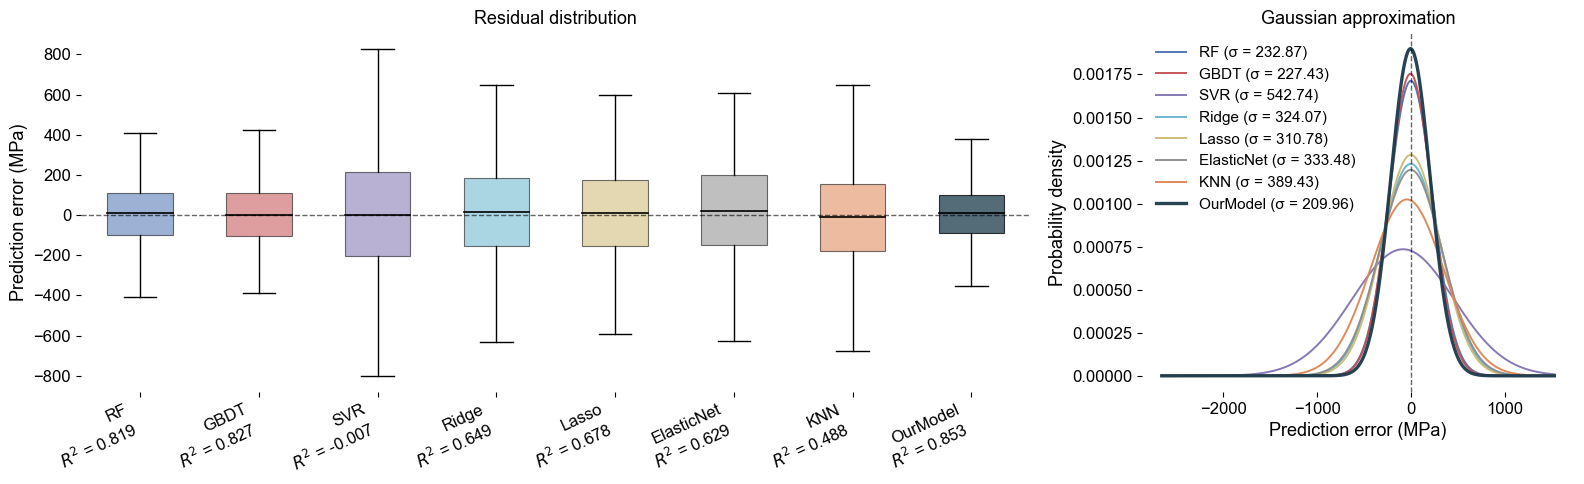

In [4]:
# ============================================================
# Nature-like muted color palette (ALL COLORED)
# ============================================================
palette = {
    "RF":        "#4C72B0",  # muted blue
    "GBDT":      "#C44E52",  # muted red
    "SVR":       "#8172B2",  # muted purple
    "Ridge":     "#64B5CD",  # soft cyan
    "Lasso":     "#CCB974",  # muted gold
    "ElasticNet":"#8C8C8C",  # neutral gray
    "KNN":       "#DD8452",  # muted orange
    "OurModel":  "#1B3A4B"   # deep blue (highlight, but restrained)
}

residuals = strength_residuals
r2_scores = {name: vals["R2"] for name, vals in strength_metrics.items()}
model_names = list(residuals.keys())
colors = {name: palette[name] for name in model_names}

# ============================================================
# Figure layout
# ============================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [2.2, 1.0]}
)

# ============================================================
# Left: Boxplot (Residuals)
# ============================================================
bp = axes[0].boxplot(
    residuals.values(),
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0)
)

for patch, name in zip(bp["boxes"], model_names):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.75 if name == "OurModel" else 0.55)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)

axes[0].axhline(0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[0].set_ylabel("Prediction error (MPa)")
axes[0].set_title("Residual distribution", pad=6)

labels = [
    f"{k}\n$R^2$ = {r2_scores[k]:.3f}"
    for k in model_names
]
axes[0].set_xticklabels(labels, rotation=25, ha="right")

for spine in axes[0].spines.values():
    spine.set_visible(False)

# ============================================================
# Right: Gaussian approximation
# ============================================================
all_res = np.concatenate(list(residuals.values()))
x = np.linspace(all_res.min(), all_res.max(), 600)

for name, res in residuals.items():
    mu, sigma = np.mean(res), np.std(res)

    axes[1].plot(
        x,
        norm.pdf(x, mu, sigma),
        color=colors[name],
        linewidth=2.4 if name == "OurModel" else 1.4,
        alpha=0.95,
        label=f"{name} (σ = {sigma:.2f})"
    )

axes[1].axvline(0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[1].set_xlabel("Prediction error (MPa)")
axes[1].set_ylabel("Probability density")
axes[1].set_title("Gaussian approximation", pad=6)

axes[1].legend(ncol=1)

for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("tensile.png", dpi=600, bbox_inches="tight")
plt.show(block=False)


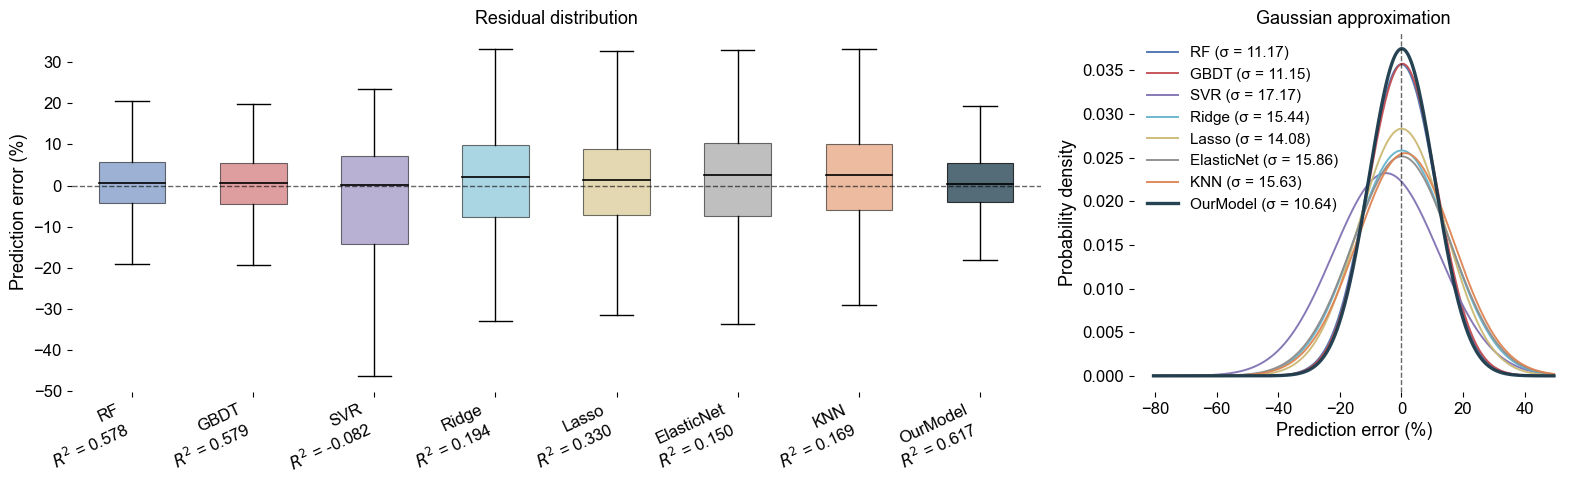

In [5]:
# ============================================================
# Nature-like muted color palette (ALL COLORED)
# ============================================================
palette = {
    "RF":        "#4C72B0",  # muted blue
    "GBDT":      "#C44E52",  # muted red
    "SVR":       "#8172B2",  # muted purple
    "Ridge":     "#64B5CD",  # soft cyan
    "Lasso":     "#CCB974",  # muted gold
    "ElasticNet":"#8C8C8C",  # neutral gray
    "KNN":       "#DD8452",  # muted orange
    "OurModel":  "#1B3A4B"   # deep blue (highlight, but restrained)
}

residuals = plasticity_residuals
r2_scores = {name: vals["R2"] for name, vals in plasticity_metrics.items()}
model_names = list(residuals.keys())
colors = {name: palette[name] for name in model_names}

# ============================================================
# Figure layout
# ============================================================
fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 5),
    gridspec_kw={"width_ratios": [2.2, 1.0]}
)

# ============================================================
# Left: Boxplot (Residuals)
# ============================================================
bp = axes[0].boxplot(
    residuals.values(),
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=1.0),
    capprops=dict(linewidth=1.0)
)

for patch, name in zip(bp["boxes"], model_names):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.75 if name == "OurModel" else 0.55)
    patch.set_edgecolor("black")
    patch.set_linewidth(0.8)

axes[0].axhline(0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[0].set_ylabel("Prediction error (%)")
axes[0].set_title("Residual distribution", pad=6)

labels = [
    f"{k}\n$R^2$ = {r2_scores[k]:.3f}"
    for k in model_names
]
axes[0].set_xticklabels(labels, rotation=25, ha="right")

for spine in axes[0].spines.values():
    spine.set_visible(False)

# ============================================================
# Right: Gaussian approximation
# ============================================================
all_res = np.concatenate(list(residuals.values()))
x = np.linspace(all_res.min(), all_res.max(), 600)

for name, res in residuals.items():
    mu, sigma = np.mean(res), np.std(res)

    axes[1].plot(
        x,
        norm.pdf(x, mu, sigma),
        color=colors[name],
        linewidth=2.4 if name == "OurModel" else 1.4,
        alpha=0.95,
        label=f"{name} (σ = {sigma:.2f})"
    )

axes[1].axvline(0, linestyle="--", linewidth=1.0, color="black", alpha=0.6)
axes[1].set_xlabel("Prediction error (%)")
axes[1].set_ylabel("Probability density")
axes[1].set_title("Gaussian approximation", pad=6)

axes[1].legend(ncol=1)

for spine in axes[1].spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("elongation.png", dpi=600, bbox_inches="tight")
plt.show(block=False)
